In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("OPENROUTER_API_KEY"):
    print("Key is there")
else:
    raise ValueError("OPENROUTER_API_KEY environment variable is not set.")


from langchain_openai import ChatOpenAI


llm_openai = ChatOpenAI(
    model="openai/gpt-oss-120b:free",
    openai_api_key=os.environ.get("OPENROUTER_API_KEY"), # Use your OpenRouter key
    openai_api_base="https://openrouter.ai/api/v1",      # Correct base URL
    temperature=0
)

Key is there


# **Autonomous SQL Database Agent**

In [2]:
from langchain_community.utilities.sql_database import SQLDatabase



uri = "sqlite:////home/devkumar-patel/Personal/sql_agent/database/invoices.db"
sql_db = SQLDatabase.from_uri(uri)


In [3]:
from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit

toolkit = SQLDatabaseToolkit(db=sql_db, llm=llm_openai)
toolkit.get_tools()

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7bf8804e2cf0>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7bf8804e2cf0>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7bf8804e2cf0>),
 QuerySQLCheckerTool(description='Use this tool to double check

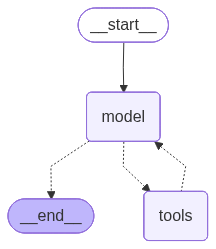

In [4]:
from langchain.agents import create_agent

agent = create_agent(llm_openai, toolkit.get_tools())

agent

In [5]:
example_query = "How much total quantity we sold for Sony Bravia 55 inch 4K OLED TV?"

events = agent.stream(
    {"messages": [("user", example_query)]},
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

How much total quantity we sold for Sony Bravia 55 inch 4K OLED TV?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (chatcmpl-tool-8574163760abb0d0)
 Call ID: chatcmpl-tool-8574163760abb0d0
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

invoice_items, invoice_summary, invoices
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (chatcmpl-tool-990e7fb542427143)
 Call ID: chatcmpl-tool-990e7fb542427143
  Args:
    table_names: invoice_items
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE invoice_items (
	id INTEGER, 
	invoice_no TEXT NOT NULL, 
	item_no INTEGER, 
	description TEXT, 
	qty REAL, 
	unit TEXT, 
	net_price REAL, 
	net_worth REAL, 
	vat_pct T

In [6]:
example_query = "How much total sales we made for Sony Bravia 55 inch 4K OLED TV without vat added?"

events = agent.stream(
    {"messages": [("user", example_query)]},
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

How much total sales we made for Sony Bravia 55 inch 4K OLED TV without vat added?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (chatcmpl-tool-91cf6e67a4ab2496)
 Call ID: chatcmpl-tool-91cf6e67a4ab2496
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

invoice_items, invoice_summary, invoices
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (chatcmpl-tool-a19dc704e8099e0b)
 Call ID: chatcmpl-tool-a19dc704e8099e0b
  Args:
    table_names: invoice_items, invoice_summary, invoices
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE invoice_items (
	id INTEGER, 
	invoice_no TEXT NOT NULL, 
	item_no INTEGER, 
	description TEXT, 
	qty REAL, 
	unit TEXT, 
	net

In [7]:
example_query = "Which product/description is most sold in terms of gross worth?"

events = agent.stream(
    {"messages": [("user", example_query)]},
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Which product/description is most sold in terms of gross worth?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (chatcmpl-tool-ba58e13bda3d61c7)
 Call ID: chatcmpl-tool-ba58e13bda3d61c7
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

invoice_items, invoice_summary, invoices
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (chatcmpl-tool-ac1002a6933d9a92)
 Call ID: chatcmpl-tool-ac1002a6933d9a92
  Args:
    table_names: invoice_items
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE invoice_items (
	id INTEGER, 
	invoice_no TEXT NOT NULL, 
	item_no INTEGER, 
	description TEXT, 
	qty REAL, 
	unit TEXT, 
	net_price REAL, 
	net_worth REAL, 
	vat_pct TEXT,